Dataset Shape: (569, 30)
Target Classes: ['malignant' 'benign']

Accuracy: 0.9649122807017544

Confusion Matrix
[[39  3]
 [ 1 71]]

Classification Report
              precision    recall  f1-score   support

           0       0.97      0.93      0.95        42
           1       0.96      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114

ROC-AUC Score: 0.9953703703703703


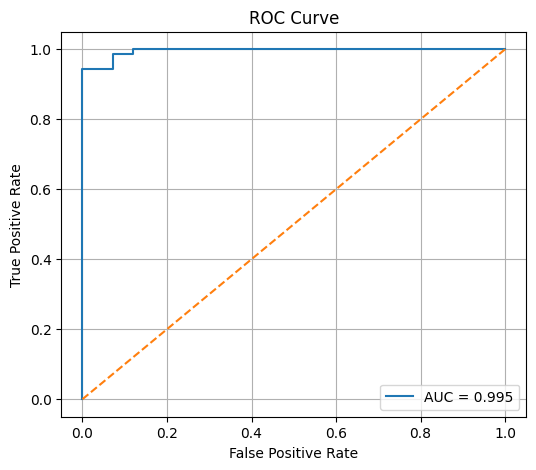


Training Logistic Regression with class_weight='balanced'

Balanced Model Accuracy
0.9385964912280702

Balanced Classification Report
              precision    recall  f1-score   support

           0       0.91      0.93      0.92        42
           1       0.96      0.94      0.95        72

    accuracy                           0.94       114
   macro avg       0.93      0.94      0.93       114
weighted avg       0.94      0.94      0.94       114



In [2]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    roc_curve,
    roc_auc_score
)


data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

print("Dataset Shape:", X.shape)
print("Target Classes:", data.target_names)


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


model = LogisticRegression(max_iter=5000)

model.fit(X_train, y_train)


y_pred = model.predict(X_test)


accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", accuracy)


cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix")
print(cm)


print("\nClassification Report")
print(classification_report(y_test, y_pred))


probabilities = model.predict_proba(X_test)[:,1]

auc = roc_auc_score(y_test, probabilities)

print("ROC-AUC Score:", auc)


fpr, tpr, threshold = roc_curve(y_test, probabilities)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label="AUC = %.3f" % auc)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()


print("\nTraining Logistic Regression with class_weight='balanced'")

balanced_model = LogisticRegression(
    class_weight='balanced',
    max_iter=5000
)

balanced_model.fit(X_train, y_train)

balanced_predictions = balanced_model.predict(X_test)

print("\nBalanced Model Accuracy")
print(accuracy_score(y_test, balanced_predictions))

print("\nBalanced Classification Report")
print(classification_report(y_test, balanced_predictions))